In [1]:
## weekly registration test
import sys
print(sys.executable)
import os
os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "16" # set the number of threads for ITK to use
from glob import glob
import wslPath

import ants
import matplotlib.pyplot as plt
import numpy as np
from skimage import io # Using scikit-image for potential multi-page support
from tqdm import tqdm
from pathlib import Path
import tifffile 

/mnt/d/Codex_folder/molecular_tracking/.venv/bin/python


In [2]:
## list of function to write
## - [] crop images to much smaller FoV to speed up computing
##      - only do like 256*256*41?
## - [] get date from file name and group them in weeks (Monday to Sunday)
## - [] find the medoid image of that week (it's likely the middle date or the first day since all images are aligned to it)

XY_SPACING_UM = 710.0 / 1024.0
Z_SPACING_UM = 5.0
SPACING_ZYX = (Z_SPACING_UM, XY_SPACING_UM, XY_SPACING_UM)


def ants_from_zyx(array, *, is_label=False):
    """Create a 3D ANTs image from a Z, Y, X NumPy array."""
    array = np.asarray(array)
    if array.ndim != 3:
        raise ValueError(f"Expected a 3D ZYX array, received shape {array.shape}")

    dtype = np.uint32 if is_label else np.float32
    return ants.from_numpy(
        array.astype(dtype, copy=False),
        spacing=SPACING_ZYX,
        origin=(0.0, 0.0, 0.0),
        direction=np.eye(3),
    )


def crop_images(image_path,crop_size=512):
    image_path = wslPath.to_posix(image_path)
    image_path = Path(image_path)
    image_array = io.imread(image_path)
    print(f"now processing {image_path.name}")    
    z,y,x = image_array.shape
    crop_size = crop_size
    crop_image_array = image_array[:,y//2-crop_size//2:y//2+crop_size//2,x//2-crop_size//2:x//2+crop_size//2]
    parent_dir = image_path.parent
    output_dir = parent_dir / f"crop_{crop_size}"
    output_fname = output_dir / f"{image_path.name.split('.tif')[0]}_crop_{crop_size}.tif"
    output_dir.mkdir(parents=True, exist_ok=True)
    io.imsave(output_fname, crop_image_array, check_contrast=False)
    print(f"Output file saved: {output_fname.name}")


In [3]:
## loop through images and make cropped images

folder_path = r"D:\_data\_newAAV_2026\weekly_registration_test"
folder_path = wslPath.to_posix(folder_path)
file_list = sorted(glob(f"{folder_path}/*.tif"))
file_list = [f for f in file_list if 'SyN' not in f] # in case there are already registered files
file_list = [f for f in file_list if 'masks' not in f] # in case there are already registered ROI mask files
file_list = [f for f in file_list if 'dark' not in f] # in case there is a dark value image

crop_size = 512

_ = [crop_images(wslPath.to_windows(f),crop_size=crop_size) for f in file_list]


now processing 20260511_G.tif
Output file saved: 20260511_G_crop_512.tif
now processing 20260511_R.tif
Output file saved: 20260511_R_crop_512.tif
now processing 20260512_G.tif
Output file saved: 20260512_G_crop_512.tif
now processing 20260512_R.tif
Output file saved: 20260512_R_crop_512.tif
now processing 20260513_G.tif
Output file saved: 20260513_G_crop_512.tif
now processing 20260513_R.tif
Output file saved: 20260513_R_crop_512.tif
now processing 20260514_G.tif
Output file saved: 20260514_G_crop_512.tif
now processing 20260514_R.tif
Output file saved: 20260514_R_crop_512.tif
now processing 20260515_G.tif
Output file saved: 20260515_G_crop_512.tif
now processing 20260515_R.tif
Output file saved: 20260515_R_crop_512.tif
now processing 20260518_G.tif
Output file saved: 20260518_G_crop_512.tif
now processing 20260518_R.tif
Output file saved: 20260518_R_crop_512.tif
now processing 20260519_G.tif
Output file saved: 20260519_G_crop_512.tif
now processing 20260519_R.tif
Output file saved: 20

In [4]:
## remove all file with SyN, masks average
# cropped_folder_path = Path(r"D:\_data\_newAAV_2026\weekly_registration_test\crop_256")
cropped_folder_path = Path(rf"D:\_data\_newAAV_2026\weekly_registration_test\crop_{crop_size}")

cropped_folder_path = wslPath.to_posix(cropped_folder_path)
file_list = glob(f"{cropped_folder_path}/*.tif")
file_list
## remove all file with SyN, masks average
for file in file_list:
    if "SyN" in file or "masks" in file or "average" in file:
        os.remove(file)
file_list = glob(f"{cropped_folder_path}/*.tif")
file_list

['/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260511_G_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260511_R_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260512_G_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260512_R_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260513_G_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260513_R_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260514_G_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260514_R_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260515_G_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260515_R_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260518_G_crop_512.tif',
 '/mnt/d/_data/_newAAV_2026/week

In [5]:
from pathlib import Path
from datetime import datetime
from collections import defaultdict

def group_files_by_week(file_list):
    week_groups = defaultdict(list)

    for file_path in file_list:
        filename = Path(file_path).name
        date_str = filename.split("_")[0]   # "20260511"

        date = datetime.strptime(date_str, "%Y%m%d").date()

        # Monday of that week
        week_start = date.fromordinal(date.toordinal() - date.weekday())

        week_groups[week_start].append(file_path)

    # Sort weeks chronologically and rename as week1, week2, ...
    week_dict = {}
    for i, week_start in enumerate(sorted(week_groups), start=1):
        week_dict[f"week{i}"] = sorted(week_groups[week_start])

    return week_dict

In [6]:
## cropped file list
# cropped_file_list = sorted(glob(f"{folder_path}/crop_256/*.tif"))
# cropped_file_list = sorted(glob(f"{folder_path}/crop_512/*.tif"))
# cropped_file_list = sorted(glob(f"{folder_path}/crop_128/*.tif"))
cropped_file_list = sorted(glob(f"{folder_path}/crop_{crop_size}/*.tif"))

cropped_file_list = [f for f in cropped_file_list if 'average' not in f]
cropped_file_list = [f for f in cropped_file_list if 'SyN' not in f]

week_dict = []
week_dict = group_files_by_week(cropped_file_list)
week_dict

# ## now try week_dic for real images

# folder_path = r"D:\_data\_newAAV_2026\weekly_registration_test"
# folder_path = wslPath.to_posix(folder_path)
# file_list = sorted(glob(f"{folder_path}/*.tif"))
# file_list = [f for f in file_list if 'SyN' not in f] # in case there are already registered files
# file_list = [f for f in file_list if 'masks' not in f] # in case there are already registered ROI mask files
# file_list = [f for f in file_list if 'dark' not in f] # in case there is a dark value image
# week_dict = group_files_by_week(file_list)
# week_dict

{'week1': ['/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260511_G_crop_512.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260511_R_crop_512.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260512_G_crop_512.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260512_R_crop_512.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260513_G_crop_512.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260513_R_crop_512.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260514_G_crop_512.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260514_R_crop_512.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260515_G_crop_512.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260515_R_crop_512.tif'],
 'week2': ['/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_512/20260518_G_crop_512.tif',
  

[GUI INFO] : WRITING LOG OUTPUT TO /home/hunglinux/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.3 
torch version:  	2.11.0+cu128
2026-07-11 08:48:55,740 [io INFO] WRITING LOG OUTPUT TO /home/hunglinux/.cellpose/run.log
2026-07-11 08:48:55,740 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.3 
torch version:  	2.11.0+cu128
2026-07-11 08:48:56,437 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-11 08:48:56,437 [core INFO] >>>> using GPU (CUDA)
2026-07-11 08:48:57,915 [models INFO] >>>> loading model /home/hunglinux/.cellpose/models/cpsam_v2


Weeks:   0%|          | 0/9 [00:00<?, ?it/s]

Processing week1 (5 red-channel images)


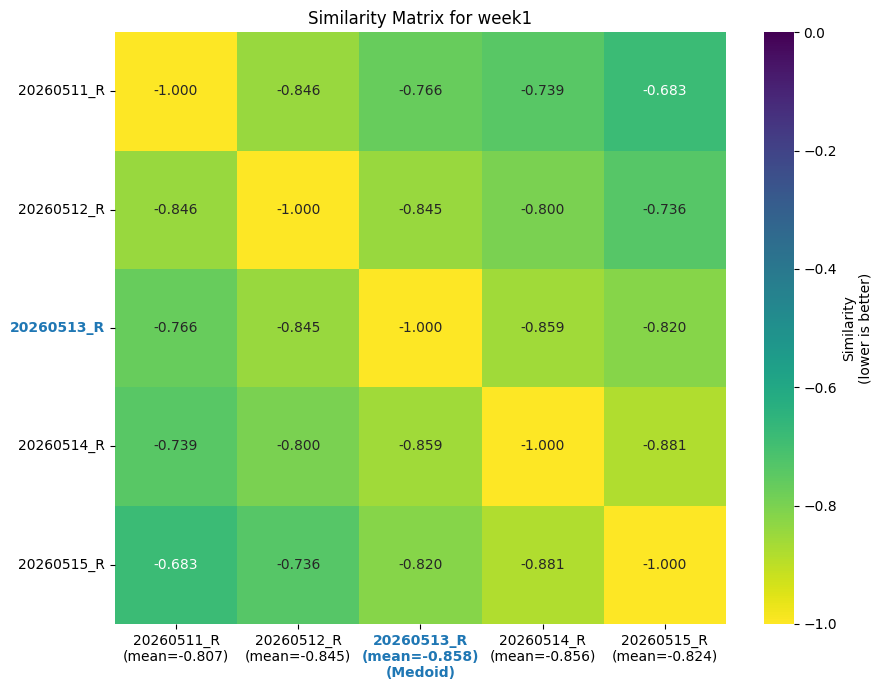

Weeks:   0%|          | 0/9 [01:26<?, ?it/s]

Medoid image for week1: 20260513_R_crop_512.tif
NumPy shape: (41, 512, 512)
ANTs shape: (41, 512, 512)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 355.0, 355.0)


                                            
Weeks:   0%|          | 0/9 [01:47<?, ?it/s]                  

Registered image saved: 20260511_R_crop_512_SyN.tif


                                            
Weeks:   0%|          | 0/9 [01:48<?, ?it/s]                  

...

Average image saved: week1_average.tif
2026-07-11 08:51:51,061 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 340.93it/s]


2026-07-11 08:51:51,280 [core INFO] running YX: 41 planes of size (512, 512)
2026-07-11 08:51:51,281 [utils INFO] 
2026-07-11 08:51:51,282 [utils INFO] 0%|          | 0/41 [00:00<?, ?it/s]
2026-07-11 08:51:51,282 [utils INFO] 
2026-07-11 08:52:05,566 [utils INFO] 100%|##########| 41/41 [00:14<00:00,  2.87it/s]
2026-07-11 08:52:05,746 [core INFO] running ZY: 512 planes of size (41, 512)
2026-07-11 08:52:05,747 [utils INFO] 
2026-07-11 08:52:05,748 [utils INFO] 0%|          | 0/256 [00:00<?, ?it/s]
2026-07-11 08:52:05,749 [utils INFO] 
2026-07-11 08:52:35,950 [utils INFO] 
2026-07-11 08:52:35,951 [utils INFO] 72%|#######1  | 184/256 [00:30<00:11,  6.09it/s]
2026-07-11 08:52:35,951 [utils INFO] 
2026-07-11 08:52:47,593 [utils INFO] 100%|##########| 256/256 [00:41<00:00,  6.12it/s]
2026-07-11 08:52:47,636 [core INFO] running ZX: 512 planes of size (41, 512)
2026-07-11 08:52:47,637 [utils INFO] 
2026-07-11 08:52:47,638 [utils INFO] 0%|          | 0/256 [00:00<?, ?it/s]
2026-07-11 08:52:47,6

/mnt/d/Codex_folder/molecular_tracking/.venv/lib/python3.12/site-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


2026-07-11 08:53:31,436 [models INFO] masks created in 1.30s


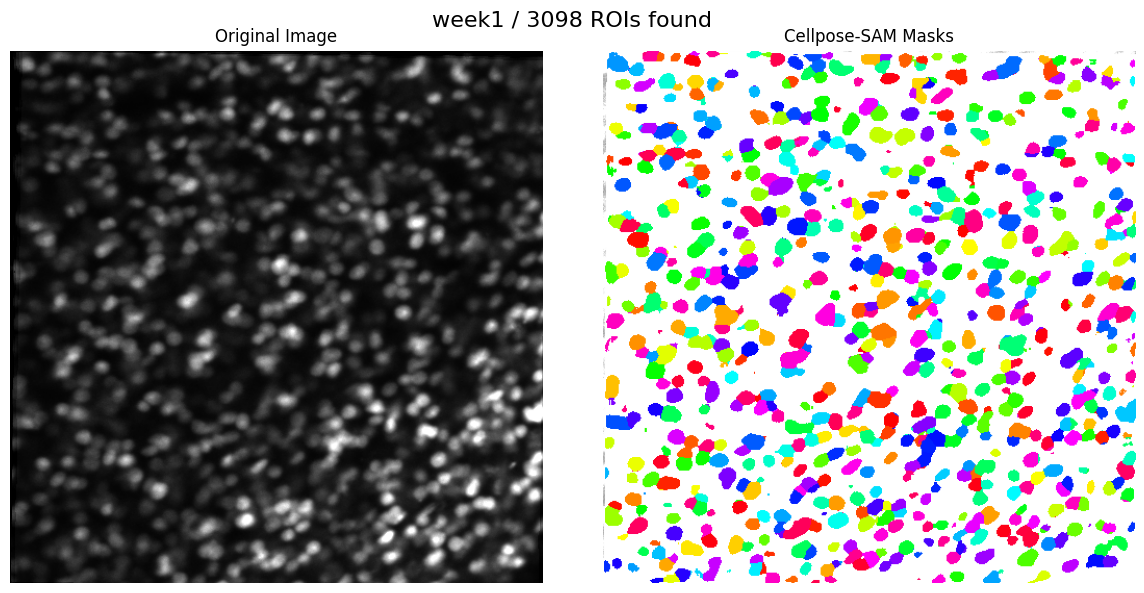

Weeks:  11%|█         | 1/9 [04:33<36:30, 273.85s/it]

Mask image saved: week1_average_cp_masks.tif
Processing week2 (4 red-channel images)


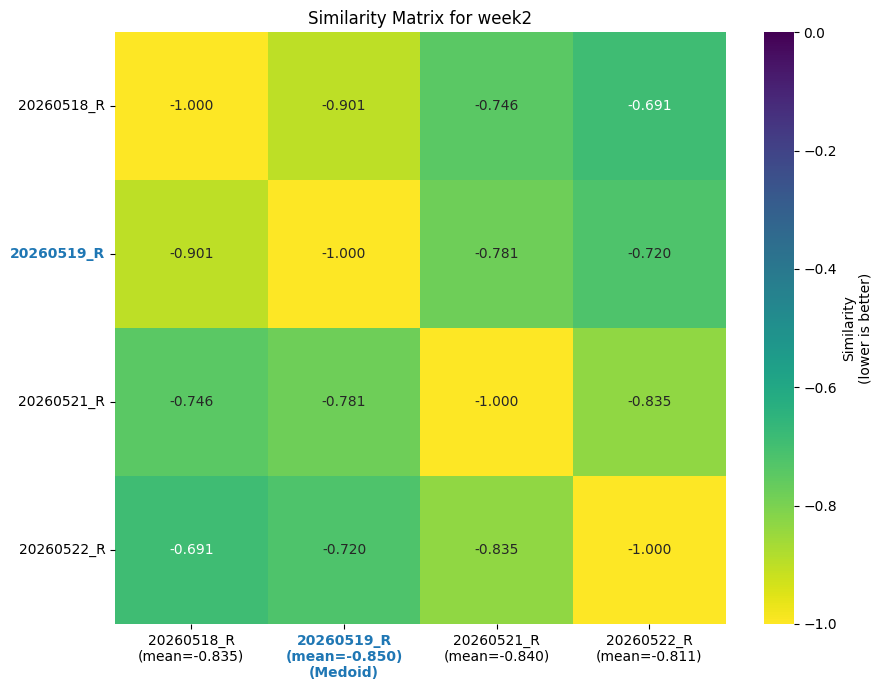

Weeks:  11%|█         | 1/9 [05:24<36:30, 273.85s/it]

Medoid image for week2: 20260519_R_crop_512.tif
NumPy shape: (41, 512, 512)
ANTs shape: (41, 512, 512)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 355.0, 355.0)


                                                     
Weeks:  11%|█         | 1/9 [05:43<36:30, 273.85s/it]         

Registered image saved: 20260518_R_crop_512_SyN.tif


                                                     
Weeks:  11%|█         | 1/9 [05:44<36:30, 273.85s/it]         

...

Registered G channel image saved: 20260522_G_crop_512_SyN.tif


Weeks:  11%|█         | 1/9 [06:37<36:30, 273.85s/it]

Average image saved: week2_average.tif
2026-07-11 08:55:35,981 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 347.77it/s]


2026-07-11 08:55:36,199 [core INFO] running YX: 41 planes of size (512, 512)
2026-07-11 08:55:36,200 [utils INFO] 
2026-07-11 08:55:36,200 [utils INFO] 0%|          | 0/41 [00:00<?, ?it/s]
2026-07-11 08:55:36,201 [utils INFO] 
2026-07-11 08:55:46,109 [utils INFO] 100%|##########| 41/41 [00:09<00:00,  4.14it/s]
2026-07-11 08:55:46,284 [core INFO] running ZY: 512 planes of size (41, 512)
2026-07-11 08:55:46,285 [utils INFO] 
2026-07-11 08:55:46,285 [utils INFO] 0%|          | 0/256 [00:00<?, ?it/s]
2026-07-11 08:55:46,287 [utils INFO] 
2026-07-11 08:56:16,326 [utils INFO] 
2026-07-11 08:56:16,327 [utils INFO] 71%|#######   | 181/256 [00:30<00:12,  6.03it/s]
2026-07-11 08:56:16,328 [utils INFO] 
2026-07-11 08:56:29,284 [utils INFO] 100%|##########| 256/256 [00:42<00:00,  5.95it/s]
2026-07-11 08:56:29,321 [core INFO] running ZX: 512 planes of size (41, 512)
2026-07-11 08:56:29,321 [utils INFO] 
2026-07-11 08:56:29,322 [utils INFO] 0%|          | 0/256 [00:00<?, ?it/s]
2026-07-11 08:56:29,3

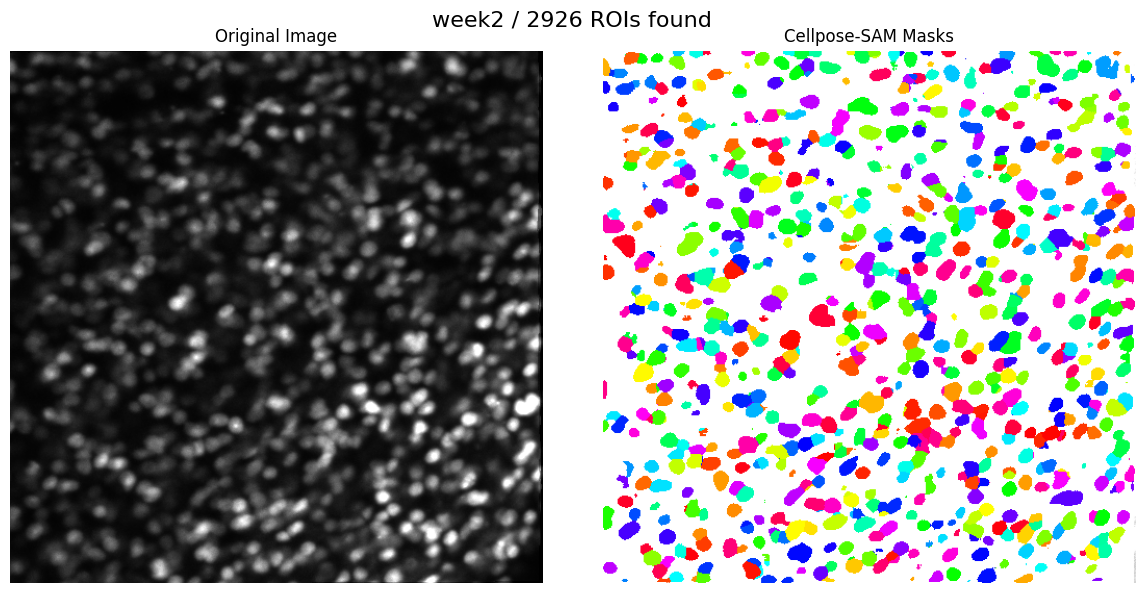

Weeks:  22%|██▏       | 2/9 [08:14<28:19, 242.73s/it]

Mask image saved: week2_average_cp_masks.tif
Processing week3 (4 red-channel images)


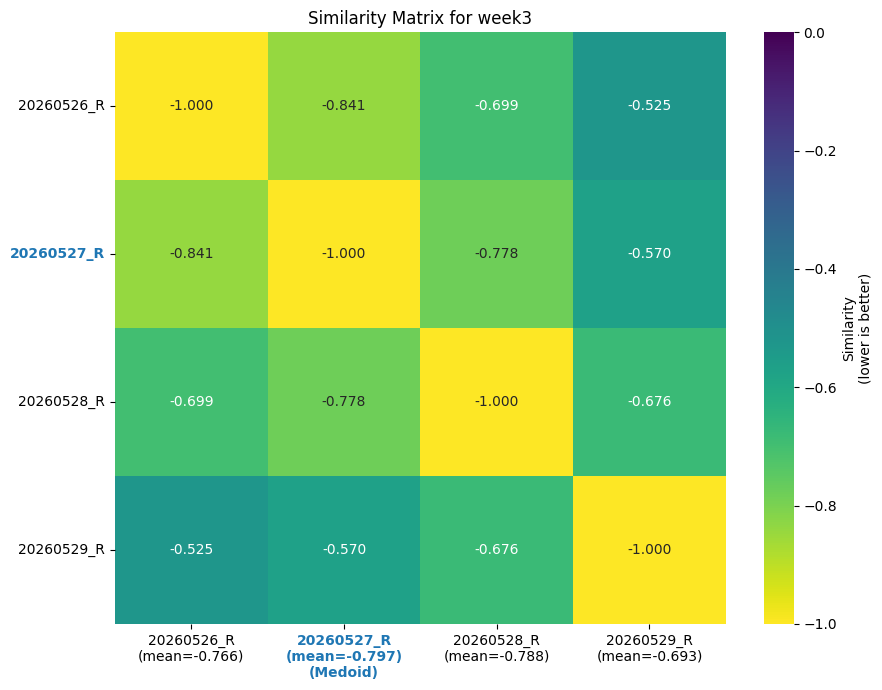

Weeks:  22%|██▏       | 2/9 [09:04<28:19, 242.73s/it]

Medoid image for week3: 20260527_R_crop_512.tif


Weeks:  22%|██▏       | 2/9 [09:04<28:19, 242.73s/it]

NumPy shape: (41, 512, 512)
ANTs shape: (41, 512, 512)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 355.0, 355.0)


                                                     
Weeks:  22%|██▏       | 2/9 [09:25<28:19, 242.73s/it]         

...

Registered G channel image saved: 20260529_G_crop_512_SyN.tif


Weeks:  22%|██▏       | 2/9 [10:16<28:19, 242.73s/it]

Average image saved: week3_average.tif
2026-07-11 08:59:15,059 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 315.00it/s]


2026-07-11 08:59:15,278 [core INFO] running YX: 41 planes of size (512, 512)
2026-07-11 08:59:15,279 [utils INFO] 
2026-07-11 08:59:15,280 [utils INFO] 0%|          | 0/41 [00:00<?, ?it/s]
2026-07-11 08:59:15,280 [utils INFO] 
2026-07-11 08:59:25,362 [utils INFO] 100%|##########| 41/41 [00:10<00:00,  4.07it/s]
2026-07-11 08:59:25,540 [core INFO] running ZY: 512 planes of size (41, 512)
2026-07-11 08:59:25,541 [utils INFO] 
2026-07-11 08:59:25,542 [utils INFO] 0%|          | 0/256 [00:00<?, ?it/s]
2026-07-11 08:59:25,543 [utils INFO] 


In [ ]:
## after grouping the files by week, automatically loop through every week in week_dict
## to find each weekly medoid, register images within the week, make the weekly average image,
## and run Cellpose-SAM on that average image.

import itertools
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from cellpose import io as cp_io
from cellpose import models, plot
from cellpose.io import imread_3D

cp_io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model='cpsam_v2')


def calculate_similarity_dict(week_list, week_name):
    similarity_dict = {}
    total_pairs = len(week_list) * (len(week_list) + 1) // 2
    pair_iter = itertools.combinations_with_replacement(week_list, 2)

    for a, b in tqdm(pair_iter, total=total_pairs, desc=f'{week_name}: affine similarity', leave=False):
        a_numpy = io.imread(a)
        b_numpy = io.imread(b)
        a_ants = ants_from_zyx(a_numpy)
        b_ants = ants_from_zyx(b_numpy)

        ## apply quick affine registration first before assessing correlation
        if a == b:
            ## the similarity of the same image is fixed to -1, we can skip the computation
            similarity = -1.0
        else:
            warped_parms = ants.registration(fixed=a_ants, moving=b_ants, type_of_transform='Affine')
            warped_b_ants = warped_parms['warpedmovout']
            similarity = ants.image_similarity(a_ants, warped_b_ants, metric_type='Correlation')

        similarity_dict[(a, b)] = similarity

    return similarity_dict


def build_similarity_matrix(week_list, similarity_dict):
    similarity_matrix = np.zeros((len(week_list), len(week_list)))
    for i, a in enumerate(week_list):
        for j, b in enumerate(week_list):
            if i == j:
                similarity_matrix[i, j] = similarity_dict[(a, b)]
            elif (a, b) in similarity_dict:
                similarity_matrix[i, j] = similarity_dict[(a, b)]
            elif (b, a) in similarity_dict:
                similarity_matrix[i, j] = similarity_dict[(b, a)]
            else:
                similarity_matrix[i, j] = 0.0

    similarity_df = pd.DataFrame(
        similarity_matrix,
        index=[Path(f).name.split('_crop')[0] for f in week_list],
        columns=[Path(f).name.split('_crop')[0] for f in week_list],
    )
    return similarity_matrix, similarity_df


def get_medoid_index(similarity_matrix):
    similarity_sums = np.nansum(similarity_matrix, axis=1)
    medoid_index = np.nanargmin(similarity_sums)
    return medoid_index, similarity_sums


def plot_similarity_heatmap(similarity_df, similarity_matrix, week_list, week_name, medoid_index):
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        similarity_df,
        annot=True,
        fmt='.3f',
        cmap='viridis_r',
        cbar_kws={'label': 'Similarity\n(lower is better)'},
        vmin=-1,
        vmax=0,
    )
    plt.title(f'Similarity Matrix for {week_name}')
    mean_similarity = np.nanmean(similarity_matrix, axis=1)
    plt.yticks(rotation=0)

    xtick_labels = [
        f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})"
        if i != medoid_index
        else f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})\n(Medoid)"
        for i, f in enumerate(week_list)
    ]
    plt.xticks(
        ticks=np.arange(len(week_list)) + 0.5,
        labels=xtick_labels,
        rotation=0,
        ha='center',
    )
    ax = plt.gca()
    for idx, label in enumerate(ax.get_xticklabels()):
        if idx == medoid_index:
            label.set_color('C0')
            label.set_fontweight('bold')
    for idx, label in enumerate(ax.get_yticklabels()):
        if idx == medoid_index:
            label.set_color('C0')
            label.set_fontweight('bold')
    plt.tight_layout()
    plt.show()
    plt.close()


weekly_registration_results = {}
week_names = sorted(week_dict, key=lambda name: int(name.replace('week', '')))

for week_name in tqdm(week_names, desc='Weeks'):
    week_n = int(week_name.replace('week', ''))
    week_list = [f for f in week_dict[week_name] if '_R' in f]

    if not week_list:
        tqdm.write(f'Skipping {week_name}: no red-channel files found.')
        continue

    tqdm.write(f'Processing {week_name} ({len(week_list)} red-channel images)')
    crop_output_dir = Path(week_list[0]).parent

    similarity_dict = calculate_similarity_dict(week_list, week_name)
    similarity_matrix, similarity_df = build_similarity_matrix(week_list, similarity_dict)
    medoid_index, similarity_sums = get_medoid_index(similarity_matrix)
    plot_similarity_heatmap(similarity_df, similarity_matrix, week_list, week_name, medoid_index)

    ## find the most similar image to all other images, which is the medoid image of that week
    medoid_image = week_list[medoid_index]
    tqdm.write(f'Medoid image for {week_name}: {Path(medoid_image).name}')

    ## perform SyN registration for all images in that week to the medoid image
    medoid_numpy = io.imread(medoid_image)
    medoid_ants = ants_from_zyx(medoid_numpy)
    tqdm.write(f'NumPy shape: {medoid_numpy.shape}')
    tqdm.write(f'ANTs shape: {medoid_ants.shape}')
    tqdm.write(f'ANTs spacing (ZYX, um): {medoid_ants.spacing}')
    tqdm.write(
        'Approximate physical extent (um): '
        f"{tuple(float(n) * float(s) for n, s in zip(medoid_ants.shape, medoid_ants.spacing))}"
    )

    registered_images = []
    for image_path in tqdm(week_list, desc=f'{week_name}: SyN registration', leave=False):
        if image_path == medoid_image:
            ## directly copy the medoid image to the output folder with "_SyN" suffix
            registered_numpy = io.imread(image_path)
            output_syn_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
            io.imsave(output_syn_path, registered_numpy, check_contrast=False)
            tqdm.write(f'Medoid image copied to: {output_syn_path.name}')

            ## same for green channel
            image_path_g = image_path.replace('_R', '_G')
            output_syn_path_g = Path(image_path_g).parent / f"{Path(image_path_g).stem}_SyN.tif"
            io.imsave(output_syn_path_g, io.imread(image_path_g), check_contrast=False)
            tqdm.write(f'Medoid G channel image copied to: {output_syn_path_g.name}')
        else:
            moving_numpy = io.imread(image_path)
            moving_ants = ants_from_zyx(moving_numpy)
            assert tuple(medoid_ants.spacing) == SPACING_ZYX
            assert tuple(moving_ants.spacing) == SPACING_ZYX
            assert medoid_ants.shape == moving_ants.shape

            reg = ants.registration(fixed=medoid_ants, moving=moving_ants, type_of_transform='SyN')
            registered_ants = reg['warpedmovout']
            registered_numpy = registered_ants.numpy().astype(np.uint16)
            output_syn_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
            io.imsave(output_syn_path, registered_numpy, check_contrast=False)
            tqdm.write(f'Registered image saved: {output_syn_path.name}')

            ## do the same for the G channel using the same transform as the R channel
            image_path_g = image_path.replace('_R', '_G')
            moving_ants_g = ants_from_zyx(io.imread(image_path_g))
            registered_ants_g = ants.apply_transforms(
                fixed=medoid_ants,
                moving=moving_ants_g,
                transformlist=reg['fwdtransforms'],
            )
            registered_numpy_g = registered_ants_g.numpy().astype(np.uint16)
            output_syn_path_g = Path(image_path_g).parent / f"{Path(image_path_g).stem}_SyN.tif"
            io.imsave(output_syn_path_g, registered_numpy_g, check_contrast=False)
            tqdm.write(f'Registered G channel image saved: {output_syn_path_g.name}')

        registered_images.append(registered_numpy.astype(np.float32, copy=False))

    ## make an average image of all registered images in that week
    average_image = np.nanmean(registered_images, axis=0)
    output_path = crop_output_dir / f'{week_name}_average.tif'
    io.imsave(output_path, average_image.astype(np.uint16), check_contrast=False)
    tqdm.write(f'Average image saved: {output_path.name}')

    ## run Cellpose-SAM on the weekly average image
    loaded_images = imread_3D(output_path.as_posix())
    masks, flows, styles = model.eval(
        loaded_images,
        do_3D=True,
        z_axis=0,
        channel_axis=3,
        min_size=100,
    )

    ## quick visualization of the middle slice
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    middle_slice = loaded_images.shape[0] // 2

    ax[0].imshow(loaded_images[middle_slice], cmap='gray', vmin=500, vmax=5000)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    mask_rgb = plot.mask_overlay(loaded_images[middle_slice], masks[middle_slice])
    ax[1].imshow(mask_rgb)
    ax[1].set_title('Cellpose-SAM Masks')
    ax[1].axis('off')

    fig.suptitle(f'{week_name} / {masks.max()} ROIs found', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    ## save masks as a tiff file
    output_mask_path = crop_output_dir / f'{week_name}_average_cp_masks.tif'
    tifffile.imwrite(output_mask_path, masks.astype(np.uint16), compression='zlib')
    tqdm.write(f'Mask image saved: {output_mask_path.name}')

    weekly_registration_results[week_name] = {
        'week_n': week_n,
        'week_list': week_list,
        'similarity_dict': similarity_dict,
        'similarity_matrix': similarity_matrix,
        'similarity_df': similarity_df,
        'similarity_sums': similarity_sums,
        'medoid_index': medoid_index,
        'medoid_image': medoid_image,
        'average_image_path': output_path.as_posix(),
        'average_mask_path': output_mask_path.as_posix(),
    }

print('\nFinished all weeks:')
for week_name, result in weekly_registration_results.items():
    print(
        f"  {week_name}: {Path(result['average_image_path']).name}, "
        f"{Path(result['average_mask_path']).name}"
    )


In [ ]:
## similarity plotting is now handled inside Cell 6 for every week in week_dict
## rerun Cell 6 when you want to regenerate all weekly medoid plots


In [ ]:
## SyN registration is now handled inside Cell 6 for every week in week_dict
## this cell is intentionally left as a placeholder


In [ ]:
## Cellpose-SAM segmentation is now handled inside Cell 6 for every week in week_dict
## this cell is intentionally left as a placeholder


In [ ]:
## weekly registration + segmentation now runs automatically in Cell 6
## per-week outputs are stored in weekly_registration_results for later inspection
## downstream exploratory cells will still use the last processed week unless you reassign from that dict


In [ ]:
## after the average images are done, let's compute the mediod image from the averaged images and then use it as the reference image to match the cell masks
average_file_list = sorted(glob(f"{folder_path}/crop_{crop_size}/*.tif"))
average_file_list = [f for f in average_file_list if 'average' in f]
average_file_list = [f for f in average_file_list if 'mask' not in f]
average_file_list = [f for f in average_file_list if 'SyN' not in f]

average_file_list

similarity_dict = {}
## loop through all pairs of images in the week and calculate their similarity, including self-similarity (which should be the highest/lowestes in MI)
for a, b in itertools.combinations_with_replacement(average_file_list, 2):
    # print(a.split('/')[-1], b.split('/')[-1])
    a_numpy = io.imread(a)
    b_numpy = io.imread(b)
    a_ants = ants_from_zyx(a_numpy)
    b_ants = ants_from_zyx(b_numpy)
    ## apply quick affine registration first before assessing correlation
    if a == b: # in case that we are comparing the same image, we don't need to register it to itself
        warped_b_ants = b_ants
        similarity = -1.0
    else:
        warped_parms = ants.registration(fixed=a_ants, moving=b_ants, type_of_transform='Affine')
        warped_b_ants = warped_parms['warpedmovout']

        # similarity = ants.image_similarity(a_ants, b_ants, metric_type='MattesMutualInformation')
        similarity = ants.image_similarity(a_ants, warped_b_ants, metric_type='Correlation') 

    print(f"Similarity between {a.split('/')[-1]} and {b.split('/')[-1]}: {similarity}")
    similarity_dict[(a, b)] = similarity

## plot simiarity matrix as a heatmap, with the file names as the x and y labels
import seaborn as sns
import pandas as pd
similarity_matrix = np.zeros((len(average_file_list), len(average_file_list)))
for i, a in enumerate(average_file_list):
    for j, b in enumerate(average_file_list):
        if i == j:
            similarity_matrix[i, j] = similarity_dict[(a, b)]
        elif (a, b) in similarity_dict:
            similarity_matrix[i, j] = similarity_dict[(a, b)]
        elif (b, a) in similarity_dict:
            similarity_matrix[i, j] = similarity_dict[(b, a)]
        else:
            similarity_matrix[i, j] = 0.0

similarity_df = pd.DataFrame(similarity_matrix, index=[Path(f).name for f in average_file_list], columns=[Path(f).name for f in average_file_list])

plt.figure(figsize=(9, 7))
sns.heatmap(similarity_df, annot=True, fmt=".3f", cmap='viridis_r', cbar_kws={'label': 'Similarity\n(lower is better)'},vmin=-1,vmax=0)
plt.title(f"Similarity Matrix Across Weeks")
mean_similarity = np.nanmean(similarity_matrix, axis=1)
# plt.xticks(ticks=np.arange(len(week_list))+0.5, labels=[f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})" for i, f in enumerate(week_list)], rotation=0, ha='center')
plt.yticks(rotation=0)
## highlight the medoid image (the one with the highest average similarity to all other images) by changing the color of its label
medoid_index = np.nanargmin(mean_similarity)
xtick_labels = [
    f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})"
    if i != medoid_index
    else f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})\n(Medoid)"
    for i, f in enumerate(average_file_list)
]
plt.xticks(
    ticks=np.arange(len(average_file_list)) + 0.5,
    labels=xtick_labels,
    rotation=0,
    ha='center'
)
ax = plt.gca()
for idx, label in enumerate(ax.get_xticklabels()):
    if idx == medoid_index:
        label.set_color('C0')
        label.set_fontweight('bold')
for idx, label in enumerate(ax.get_yticklabels()):
    if idx == medoid_index:
        label.set_color('C0')
        label.set_fontweight('bold')
plt.tight_layout()
plt.show()


## find the most similar image to all other images, which is the medoid image of that week
similarity_sums = np.nansum(similarity_matrix, axis=1)
medoid_index = np.nanargmin(similarity_sums) # find the one with the smallest average distance to all other images
medoid_image = average_file_list[medoid_index]
print(f"Medoid image for across weeks: {Path(medoid_image).name}")



In [ ]:
## then let's try do SyN registration from all averaged images to the mediod image, and then transform their cp_masks
## perform SyN registration for all images in that week to the medoid image, and save the registered images in the same folder with "_SyN" suffix
medoid_ants = ants_from_zyx(io.imread(medoid_image))
for image_path in average_file_list:
    if image_path == medoid_image:
        ## directly copy the medoid image to the output folder with "_SyN" suffix
        output_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
        io.imsave(output_path, io.imread(image_path), check_contrast=False)
        print(f"Medoid image copied to: {output_path.name}")
        ## same for green channel
        output_path_g = Path(image_path.replace('_R', '_G')).parent / f"{Path(image_path.replace('_R', '_G')).stem}_SyN.tif"
        io.imsave(output_path_g, io.imread(image_path.replace('_R', '_G')), check_contrast=False)
        print(f"Medoid G channel image copied to: {output_path_g.name}")
        ## same for the masks
        mask_path = image_path.replace("average","average_cp_masks")
        output_fname_mask = Path(mask_path).parent / f"{Path(mask_path).stem}_SyN.tif"
        io.imsave(output_fname_mask, io.imread(mask_path), compression='deflate', photometric="minisblack", check_contrast=False)
        print(f"Medoid mask image copied to: {output_fname_mask.name}")
        continue
    moving_ants = ants_from_zyx(io.imread(image_path))
    assert tuple(medoid_ants.spacing) == SPACING_ZYX
    assert tuple(moving_ants.spacing) == SPACING_ZYX
    assert medoid_ants.shape == moving_ants.shape
    reg = ants.registration(fixed=medoid_ants, moving=moving_ants, type_of_transform='SyN')
    registered_ants = reg['warpedmovout']
    registered_numpy = registered_ants.numpy()
    output_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
    io.imsave(output_path, registered_numpy.astype(np.uint16), check_contrast=False)
    print(f"Registered image saved: {output_path.name}")

    ## and do maks transformation too 
    ## note this is a forward transformation, not inverse
    mask_path = image_path.replace("average","average_cp_masks")
    ROI_mask_ants = ants_from_zyx(io.imread(mask_path), is_label=True)
    warped_ROI_mask = ants.apply_transforms(fixed=medoid_ants, moving=ROI_mask_ants, transformlist=reg['fwdtransforms'], interpolator='genericLabel')
    assert warped_ROI_mask.shape == registered_ants.shape
    assert tuple(warped_ROI_mask.spacing) == tuple(registered_ants.spacing)
    assert tuple(warped_ROI_mask.origin) == tuple(registered_ants.origin)
    assert np.array_equal(np.asarray(warped_ROI_mask.direction), np.asarray(registered_ants.direction))
    warped_ROI_mask_numpy = warped_ROI_mask.numpy().astype(np.uint16)
    output_fname_mask = Path(mask_path).parent / f"{Path(mask_path).stem}_SyN.tif"
    io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)
    print(f"Output file saved: {output_fname_mask.name.split('/')[-1]}")


# ## make an average image of all registered images in that week, and save it as "weekX_average.tif"
# registered_images = []
# for image_path in average_file_list:
#     if image_path == medoid_image:
#         registered_images.append(io.imread(image_path))
#     else:
#         registered_images.append(io.imread(Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"))
# average_image = np.nanmean(registered_images, axis=0)
# output_path = Path(folder_path) /"crop_256" / f"grand_average.tif"
# io.imsave(output_path, average_image.astype(np.uint16), check_contrast=False)
# print(f"Average image saved: {output_path.name}")


In [ ]:
## can stop here for now

In [ ]:
## let's load the outputed csv file and see what it looks like now

matched_roi_csv_path = Path(folder_path) /"crop_256" / f"roi_match_runs" / "20260710_test.csv"
matched_roi_csv_path
df_matched_rois = pd.read_csv(matched_roi_csv_path)
df_matched_rois.head(10)

df_matched_rois['n_days_present'].unique()


In [ ]:
## okay it seems like that doesn't work so well to perform SyN on the average image
## let's just try ROI mask matching then




In [ ]:
similarity_matrix_after

In [ ]:
## let's compare again the similarity matrix after registration, to see if the similarity has improved and if the medoid image is still the same
## also add the average image to the similarity matrix to see how similar it is to the medoid image and other images in that week

similarity_dict_after = {}
registered_week_list = []
for image_path in week_list:
    if image_path == medoid_image:
        registered_week_list.append(image_path)
    else:
        registered_week_list.append((Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif").as_posix())
registered_week_list.append(output_path.as_posix()) # add the average image to the list for similarity comparison
for a, b in itertools.combinations_with_replacement(registered_week_list, 2):
    # print(a.split('/')[-1], b.split('/')[-1])
    a_numpy = io.imread(a)
    b_numpy = io.imread(b)
    a_ants = ants_from_zyx(a_numpy)
    b_ants = ants_from_zyx(b_numpy)
    # similarity = ants.image_similarity(a_ants, b_ants, metric_type='MattesMutualInformation')
    similarity = -ants.image_similarity(a_ants, b_ants, metric_type='Correlation') ## convert to positive similarity, higher is more similar

    print(f"Similarity between {a.split('/')[-1]} and {b.split('/')[-1]}: {similarity}")
    similarity_dict_after[(a, b)] = similarity
similarity_matrix_after = np.zeros((len(registered_week_list), len(registered_week_list)))
for i, a in enumerate(registered_week_list):
    for j, b in enumerate(registered_week_list):
        if i == j:
            similarity_matrix_after[i, j] = similarity_dict_after[(a, b)]
        elif (a, b) in similarity_dict_after:
            similarity_matrix_after[i, j] = similarity_dict_after[(a, b)]
        elif (b, a) in similarity_dict_after:
            similarity_matrix_after[i, j] = similarity_dict_after[(b, a)]
        else:
            similarity_matrix_after[i, j] = 0.0
similarity_df_after = pd.DataFrame(similarity_matrix_after, index=[Path(f).name.split('_crop')[0] for f in registered_week_list], columns=[Path(f).name.split('_crop')[0] for f in registered_week_list])
plt.figure(figsize=(9, 7))
sns.heatmap(similarity_df_after, annot=True, fmt=".3f", cmap='viridis', cbar_kws={'label': 'Similarity\n(higher is better)'},vmin=0,vmax=1)
plt.title(f"Similarity Matrix for Week {week_n} After Registration")
mean_similarity_after = np.nanmean(similarity_matrix_after, axis=1)
medoid_index_after = np.nanargmax(mean_similarity_after)

xtick_labels_after = [
    f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity_after[i]:.3f})"
    if i != medoid_index_after
    else f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity_after[i]:.3f})\n(Most similar)"
    for i, f in enumerate(registered_week_list)
]
plt.xticks(
    ticks=np.arange(len(registered_week_list)) + 0.5,
    labels=xtick_labels_after,
    rotation=0,
    ha='center'
)
ax = plt.gca()
for idx, label in enumerate(ax.get_xticklabels()):
    if idx == medoid_index_after:
        label.set_color('C0')
        label.set_fontweight('bold')
for idx, label in enumerate(ax.get_yticklabels()):
    if idx == medoid_index_after:
        label.set_color('C0')
        label.set_fontweight('bold')
plt.tight_layout()
plt.show()



In [ ]:
output_path

In [ ]:
medoid_image

In [ ]:
## find the most similar image to all other images, which is the medoid image of that week
similarity_sums = np.nansum(similarity_matrix, axis=1)
medoid_index = np.nanargmin(similarity_sums) # find the one with the smallest average distance to all other images
medoid_image = week_list[medoid_index]
print(f"Medoid image for week {week_n}: {Path(medoid_image).name}")



In [ ]:
np.triu_indices_from(similarity_matrix,k=1)

In [ ]:
np.triu_indices(similarity_matrix)

In [ ]:
up_triangle_idx = np.triu_indices_from(similarity_matrix,k=-)
similarity_matrix[up_triangle_idx] = np.nan

plt.imshow(similarity_matrix, cmap='viridis')

In [ ]:
ants.image_similarity(b_ants, b_ants, metric_type='MattesMutualInformation')